# Part 5: Post-training

This notebook walks through the key ideas from the post-training lecture using a **real but tiny model (135M parameters)**:
[`SmolLM2-135M-Instruct`](https://huggingface.co/HuggingFaceTB/SmolLM2-135M-Instruct).

**What we cover:**
1. Chat templates
2. Supervised Fine-Tuning (SFT)
3. Direct Preference Optimization (DPO)
4. LoRA: parameter-efficient fine-tuning
5. GRPO (group-relative advantages)

**Runtime:** each training section runs in **1–3 minutes** on a modern CPU or Apple Silicon.

In [1]:
# !pip install transformers trl peft datasets torch matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM

device = (
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: mps


## 1. The base model and chat templates

We load `SmolLM2-135M-Instruct`, a tiny model that has already been aligned.
Understanding how it was produced is the goal of this notebook.

In [2]:
MODEL = "HuggingFaceTB/SmolLM2-135M-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.bfloat16).to(device).eval()

print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Parameters: 134.5M


### 1.1 Chat templates

Instruct models expect conversations in a specific format.
SmolLM2 uses **ChatML**: `<|im_start|>role\ncontent<|im_end|>`.
`apply_chat_template` handles all the formatting automatically.

In [3]:
def make_prompt(user_message, system="You are a helpful assistant."):
    messages = [
        {"role": "system", "content": system},
        {"role": "user",   "content": user_message},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

prompt = make_prompt("What is the capital of France?")
print(repr(prompt))
print()
print("--- Rendered ---")
print(prompt)

'<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat is the capital of France?<|im_end|>\n<|im_start|>assistant\n'

--- Rendered ---
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of France?<|im_end|>
<|im_start|>assistant



In [4]:
def generate(prompt_text, mdl=None, tok=None, max_new_tokens=80):
    if mdl is None: mdl = model
    if tok is None: tok = tokenizer
    inputs = tok(prompt_text, return_tensors="pt").to(device)
    # Stop at end-of-turn (<|im_end|>) or start-of-turn (<|im_start|>),
    # whichever comes first — eos_token_id alone is </s> for this tokenizer
    stop_ids = list({tok.eos_token_id,
                     tok.convert_tokens_to_ids("<|im_end|>"),
                     tok.convert_tokens_to_ids("<|im_start|>")})
    with torch.no_grad():
        out = mdl.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, pad_token_id=tok.eos_token_id,
            eos_token_id=stop_ids,
        )
    new = out[0][inputs["input_ids"].shape[1]:]
    return tok.decode(new, skip_special_tokens=True)

for q in [
    "What is the capital of France?",
    "What is 7 × 8?",
    "Explain gradient descent in two sentences.",
]:
    print(f"Q: {q}")
    print(f"A: {generate(make_prompt(q))}")
    print()

Q: What is the capital of France?
A: The capital of France is Paris.

Q: What is 7 × 8?
A: To find 7 × 8, we need to follow these steps:

First, we multiply 7 by itself 7 times:

7 × 7 = 49

Then, we multiply 49 by 8:

49 × 8 = 396

So, 7 × 8 is equal to 396.

Q: Explain gradient descent in two sentences.
A: Gradient descent is a method for updating the parameters of a neural network by minimizing the loss function. It starts with a guess for the parameters, then iteratively updates the parameters by minimizing the loss function, until convergence, at which point the model converges to a local minimum.



## 2. Supervised Fine-Tuning (SFT)

SFT trains on (prompt, response) pairs with **loss masking**: the cross-entropy loss is computed only on response tokens; the prompt is ignored.

### 2.1 Loss masking: why it matters

Without masking, the model would be penalized for not predicting the prompt itself, wasting gradient signal on text we already know.

In [5]:
def show_loss_masking(prompt_text, response_text):
    """Print which tokens are masked (prompt) vs. trained on (response)."""
    prompt_ids   = tokenizer.encode(prompt_text,   add_special_tokens=False)
    response_ids = tokenizer.encode(" " + response_text, add_special_tokens=False)
    full_ids = prompt_ids + response_ids
    labels   = [-100] * len(prompt_ids) + response_ids

    print(f"{'Token':<22} Status")
    print("-" * 38)
    for tok_id, label in zip(full_ids, labels):
        tok    = tokenizer.decode([tok_id])
        status = "MASKED (no gradient)" if label == -100 else "TRAIN  ← gradient flows here"
        print(f"  {tok!r:<20} {status}")
    return labels

labels = show_loss_masking("What is the capital of France?", "The capital of France is Paris.")

Token                  Status
--------------------------------------
  'What'               MASKED (no gradient)
  ' is'                MASKED (no gradient)
  ' the'               MASKED (no gradient)
  ' capital'           MASKED (no gradient)
  ' of'                MASKED (no gradient)
  ' France'            MASKED (no gradient)
  '?'                  MASKED (no gradient)
  ' The'               TRAIN  ← gradient flows here
  ' capital'           TRAIN  ← gradient flows here
  ' of'                TRAIN  ← gradient flows here
  ' France'            TRAIN  ← gradient flows here
  ' is'                TRAIN  ← gradient flows here
  ' Paris'             TRAIN  ← gradient flows here
  '.'                  TRAIN  ← gradient flows here


### 2.2 SFT dataset

We create 45 simple Q&A pairs and fine-tune using `trl.SFTTrainer`.

In [6]:
from datasets import Dataset

BASE_MODEL    = "HuggingFaceTB/SmolLM2-135M"   # base, not instruct
sft_tokenizer = AutoTokenizer.from_pretrained(MODEL)   # use instruct tokenizer (has chat template)
sft_tokenizer.pad_token = sft_tokenizer.eos_token

raw_data = [
    # Geography
    ("What is the capital of France?",        "The capital of France is Paris."),
    ("What is the capital of Germany?",       "The capital of Germany is Berlin."),
    ("What is the capital of Japan?",         "The capital of Japan is Tokyo."),
    ("What is the capital of Brazil?",        "The capital of Brazil is Brasilia."),
    ("What is the largest ocean?",            "The Pacific Ocean is the largest ocean on Earth."),
    ("Which continent is Australia on?",      "Australia is its own continent."),
    ("What is the longest river?",            "The Nile is generally considered the longest river."),
    # Math
    ("What is 12 + 15?",                      "12 + 15 = 27."),
    ("What is 7 × 8?",                        "7 × 8 = 56."),
    ("What is the square root of 144?",       "The square root of 144 is 12."),
    ("What is 100 divided by 4?",             "100 divided by 4 equals 25."),
    ("Is 17 a prime number?",                 "Yes, 17 is a prime number."),
    ("What is 2 to the power of 10?",         "2 to the power of 10 equals 1024."),
    # Science
    ("What is the speed of light?",           "The speed of light is approximately 300,000 km/s."),
    ("What is the chemical formula for water?", "The chemical formula for water is H2O."),
    ("What planet is closest to the Sun?",    "Mercury is the closest planet to the Sun."),
    ("What is photosynthesis?",               "Photosynthesis is how plants convert sunlight and CO2 into sugar and oxygen."),
    ("What is the atomic number of carbon?",  "Carbon has atomic number 6."),
    ("What is DNA?",                          "DNA carries genetic information in living organisms."),
    # History
    ("In what year did World War II end?",    "World War II ended in 1945."),
    ("Who wrote the Iliad?",                  "The Iliad is attributed to Homer."),
    ("When did the French Revolution begin?", "The French Revolution began in 1789."),
    # Programming
    ("What does CPU stand for?",              "CPU stands for Central Processing Unit."),
    ("What is a Python list?",                "A Python list is an ordered, mutable collection of elements."),
    ("What does print() do in Python?",       "The print() function outputs text to the console."),
    ("What is a function in programming?",    "A function is a reusable block of code that performs a specific task."),
    ("What is an API?",                       "An API allows different software programs to communicate with each other."),
    # ML
    ("What is a neural network?",             "A neural network is a machine learning model made of layers of connected neurons."),
    ("What is overfitting?",                  "Overfitting occurs when a model memorizes training data and performs poorly on new data."),
    ("What is gradient descent?",             "Gradient descent iteratively adjusts parameters to minimize a loss function."),
    ("What is a transformer in ML?",          "A transformer is a neural network that uses self-attention to process sequences in parallel."),
    ("What does fine-tuning mean?",           "Fine-tuning means continuing to train a pre-trained model on a smaller, task-specific dataset."),
    ("What is a token in NLP?",               "A token is a unit of text (roughly a word or sub-word) that a language model processes."),
    # General
    ("What is the boiling point of water?",   "Water boils at 100 degrees Celsius at standard pressure."),
    ("How many days are in a leap year?",     "A leap year has 366 days."),
    ("Who painted the Mona Lisa?",            "Leonardo da Vinci painted the Mona Lisa."),
    ("Give me three tips for studying.",
     "1. Space out your sessions instead of cramming. 2. Test yourself rather than just re-reading. 3. Get enough sleep."),
    ("How do I stay hydrated?",
     "Drink water regularly throughout the day. Around 2 litres per day is a common guideline."),
    ("Explain machine learning in simple terms.",
     "Machine learning is teaching a computer to learn from examples instead of writing explicit rules."),
    ("What are the benefits of exercise?",
     "Regular exercise improves cardiovascular health, strengthens muscles, boosts mood, and aids weight management."),
    ("How does a search engine work?",
     "A search engine crawls the web, indexes pages, and ranks them by relevance when you search."),
    ("What is recursion?",
     "Recursion is when a function calls itself. For example, a factorial function calls itself with a smaller number until the base case."),
    ("What does HTTP stand for?",
     "HTTP stands for HyperText Transfer Protocol, the foundation of data communication on the web."),
    ("What is the speed of sound in air?",
     "Sound travels at about 343 metres per second in air at room temperature."),
]

def format_for_sft(prompt_text, response_text):
    messages = [
        {"role": "system",    "content": "You are a helpful assistant."},
        {"role": "user",      "content": prompt_text},
        {"role": "assistant", "content": response_text},
    ]
    return sft_tokenizer.apply_chat_template(messages, tokenize=False)

sft_dataset = Dataset.from_dict({
    "text": [format_for_sft(p, r) for p, r in raw_data]
})
print(f"Dataset: {len(sft_dataset)} examples")
print()
print("First formatted example:")
print(sft_dataset[0]["text"])

Dataset: 44 examples

First formatted example:
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of France?<|im_end|>
<|im_start|>assistant
The capital of France is Paris.<|im_end|>



### 2.3 Fine-tuning with SFTTrainer

We load the **base** (unaligned) SmolLM2-135M and fine-tune it on our dataset.

In [7]:
from trl import SFTTrainer, SFTConfig

sft_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=torch.bfloat16).to(device)

sft_config = SFTConfig(
    output_dir="/tmp/sft_smollm",
    num_train_epochs=10,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    warmup_steps=10,
    logging_steps=10,
    save_strategy="no",
    bf16=(device != "cpu"),
    report_to="none",
    max_length=256,
)

trainer = SFTTrainer(
    model=sft_model,
    args=sft_config,
    train_dataset=sft_dataset,
    processing_class=sft_tokenizer,
)

print("Starting SFT...")
result = trainer.train()
sft_model.eval()
print(f"Done. Final loss: {result.training_loss:.4f}")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

/var/folders/n8/m5ycpkr13jj_w9jqvc_5djqw0000gp/T/ipykernel_183/2370601264.py:5: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  sft_config = SFTConfig(


Adding EOS to train dataset:   0%|          | 0/44 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/44 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1, 'pad_token_id': 2}.


Starting SFT...


/Users/nath/Documents/Teaching/LLM-course/llm_mva/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,4.627153
20,1.468940
30,0.660659
40,0.412373
50,0.340999
60,0.299525


Done. Final loss: 1.3016


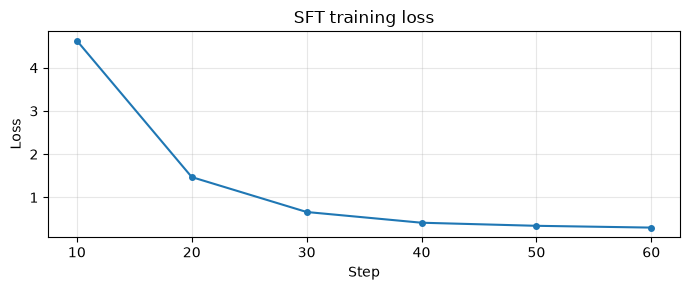

In [8]:
# Plot training loss
log = trainer.state.log_history
steps  = [x["step"] for x in log if "loss" in x]
losses = [x["loss"]  for x in log if "loss" in x]

plt.figure(figsize=(7, 3))
plt.plot(steps, losses, marker="o", markersize=4)
plt.xlabel("Step"); plt.ylabel("Loss")
plt.title("SFT training loss"); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [9]:
# Test the SFT model
for q in ["What is the capital of France?", "What is 7 × 8?", "What is a neural network?"]:
    ans = generate(make_prompt(q), mdl=sft_model, tok=sft_tokenizer)
    print(f"Q: {q}")
    print(f"A: {ans}")
    print()

Q: What is the capital of France?
A: The capital of France is Paris.

Q: What is 7 × 8?
A: 7 × 8 = 56.

Q: What is a neural network?
A: A neural network is a machine learning model made of layers of connected neurons.



## 3. Direct Preference Optimization (DPO)

DPO trains directly from **preference pairs** (chosen vs. rejected responses).

**Key insight**: RLHF implicitly defines an optimal policy in terms of a reward. DPO inverts this: it expresses the reward in terms of the policy and trains directly, eliminating the reward model.

$$\mathcal{L}_{\text{DPO}} = -\log\sigma\!\left(\beta \left[\log\frac{\pi_\theta(y_w|x)}{\pi_{\text{ref}}(y_w|x)} - \log\frac{\pi_\theta(y_l|x)}{\pi_{\text{ref}}(y_l|x)}\right]\right)$$

### 3.1 The DPO loss: manual computation

In [10]:
def sequence_logprob(mdl, tok, text):
    """Total log-probability of text under model mdl."""
    ids = tok(text, return_tensors="pt").input_ids.to(device)
    with torch.no_grad():
        logits = mdl(ids).logits              # (1, T, vocab)
    log_p = F.log_softmax(logits[:, :-1], dim=-1)   # (1, T-1, vocab)
    target = ids[:, 1:]                               # (1, T-1)
    return log_p.gather(2, target.unsqueeze(-1)).squeeze(-1).sum().item()

# Manual DPO loss on one pair
system   = "You are a helpful assistant."
prompt   = "What is the capital of France?"
chosen   = "The capital of France is Paris."
rejected = "The capital of France is Lyon."

def fmt(answer):
    msgs = [{"role":"system","content":system},
            {"role":"user","content":prompt},
            {"role":"assistant","content":answer}]
    return sft_tokenizer.apply_chat_template(msgs, tokenize=False)

lp_c = sequence_logprob(sft_model, sft_tokenizer, fmt(chosen))
lp_r = sequence_logprob(sft_model, sft_tokenizer, fmt(rejected))
# before DPO, both ratios equal zero → loss = -log σ(0) ≈ 0.693
print(f"log P(chosen):   {lp_c:.2f}")
print(f"log P(rejected): {lp_r:.2f}")
print(f"DPO ratio (β=0.1): {0.1*(lp_c - lp_r):.4f}")
print(f"Initial DPO loss: {-F.logsigmoid(torch.tensor(0.1*(lp_c - lp_r))).item():.4f}")
print("  (loss < ln(2)=0.693 means model already prefers the chosen response)")

log P(chosen):   -6.99
log P(rejected): -16.44
DPO ratio (β=0.1): 0.9445
Initial DPO loss: 0.3285
  (loss < ln(2)=0.693 means model already prefers the chosen response)


### 3.2 Preference dataset

In [11]:
from datasets import Dataset

preference_data = [
    # Factual accuracy
    ("What is the capital of France?",
     "The capital of France is Paris.",
     "The capital of France is Lyon."),
    ("What is 7 × 8?",
     "7 × 8 = 56.",
     "7 × 8 = 54."),
    ("What is the boiling point of water?",
     "Water boils at 100 degrees Celsius at standard pressure.",
     "Water boils at 90 degrees Celsius."),
    ("Who wrote Romeo and Juliet?",
     "Romeo and Juliet was written by William Shakespeare.",
     "Romeo and Juliet was written by Charles Dickens."),
    ("What is the chemical symbol for gold?",
     "The chemical symbol for gold is Au.",
     "The chemical symbol for gold is Go."),
    # Conciseness (good: clear and brief; bad: too verbose or too vague)
    ("What is 2 + 2?",
     "2 + 2 = 4.",
     "Well, when we think about the addition of two integers, specifically 2 and 2, we arrive at 4, which is a well-known mathematical fact."),
    ("Define photosynthesis.",
     "Photosynthesis is the process by which plants use sunlight to convert CO2 and water into glucose and oxygen.",
     "Photosynthesis is a process. It happens in plants. Plants do it."),
    ("What is machine learning?",
     "Machine learning is teaching computers to learn from data instead of being explicitly programmed.",
     "Machine learning is like, when computers do stuff with data."),
    # Helpfulness
    ("How do I make pasta?",
     "Boil salted water, add pasta, cook for 8-10 minutes until al dente, drain and serve with sauce.",
     "I don't know how to cook."),
    ("Explain gradient descent.",
     "Gradient descent iteratively adjusts model parameters in the direction that reduces the loss.",
     "Gradient descent is a thing in machine learning."),
    # Safety / honesty
    ("Should I mix bleach and ammonia?",
     "No. Mixing bleach and ammonia produces toxic chloramine gas. Never do this.",
     "Sure, mixing household chemicals can be fun!"),
    ("Is it safe to drive after drinking alcohol?",
     "No. Alcohol impairs judgment and reaction time. Never drive after drinking.",
     "It depends on how much you drank."),
    ("What is the population of Mars?",
     "Mars has no permanent human population as of 2025.",
     "The population of Mars is approximately 50,000 colonists."),
    # Format
    ("List three programming languages.",
     "Three popular languages are Python, JavaScript, and Java.",
     "Language 1: Python\nLanguage 2: JavaScript\nLanguage 3: Java\nLanguage 4: C\nLanguage 5: C++"),
    ("Give me a short greeting.",
     "Hello! How can I help you today?",
     "Greetings and salutations! I am here and ready to assist you with absolutely anything!"),
    # Instruction following
    ("Reply with exactly one word: what is 1+1?",
     "Two.",
     "The answer to 1+1 is 2, which is a basic arithmetic fact."),
    ("Translate to French: Good morning.",
     "Bonjour.",
     "Good morning is an English greeting used in the morning hours."),
    ("What is recursion?",
     "Recursion is when a function calls itself, reducing the problem at each step until a base case.",
     "Recursion is recursion."),
    ("What does HTTP stand for?",
     "HTTP stands for HyperText Transfer Protocol, the foundation of web communication.",
     "HTTP is a protocol used on the internet."),
    ("What are the planets in the solar system?",
     "The eight planets are Mercury, Venus, Earth, Mars, Jupiter, Saturn, Uranus, and Neptune.",
     "The solar system has many planets, including Earth and some others."),
]

system_msg = "You are a helpful assistant."

# TRL DPOTrainer concatenates prompt + chosen to form the full chosen sequence,
# so 'chosen'/'rejected' must be the response only (not the full conversation).
def make_dpo_prompt(q):
    msgs = [{"role": "system", "content": system_msg}, {"role": "user", "content": q}]
    return sft_tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

def make_dpo_response(answer):
    im_end = sft_tokenizer.decode([sft_tokenizer.convert_tokens_to_ids("<|im_end|>")])
    return answer + im_end

dpo_dataset = Dataset.from_list([
    {
        "prompt":   make_dpo_prompt(p),
        "chosen":   make_dpo_response(c),
        "rejected": make_dpo_response(r),
    }
    for p, c, r in preference_data
])
print(f"DPO dataset: {len(dpo_dataset)} preference pairs")
print()
print("prompt  :", repr(dpo_dataset[0]["prompt"][-60:]))
print("chosen  :", repr(dpo_dataset[0]["chosen"]))
print("rejected:", repr(dpo_dataset[0]["rejected"]))

DPO dataset: 20 preference pairs

prompt  : 't is the capital of France?<|im_end|>\n<|im_start|>assistant\n'
chosen  : 'The capital of France is Paris.<|im_end|>'
rejected: 'The capital of France is Lyon.<|im_end|>'


### 3.3 Fine-tuning with DPOTrainer

In [12]:
from trl import DPOTrainer, DPOConfig

dpo_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=torch.bfloat16).to(device)
dpo_model.load_state_dict(sft_model.state_dict())   # start from the SFT checkpoint

dpo_config = DPOConfig(
    output_dir="/tmp/dpo_smollm",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    beta=0.5,
    logging_steps=5,
    save_strategy="no",
    bf16=(device != "cpu"),
    report_to="none",
    max_length=256,
)

dpo_trainer = DPOTrainer(
    model=dpo_model,
    args=dpo_config,
    train_dataset=dpo_dataset,
    processing_class=sft_tokenizer,
)
print("Starting DPO...")
dpo_result = dpo_trainer.train()
dpo_model.eval()
print(f"Done. Final loss: {dpo_result.training_loss:.4f}")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1, 'pad_token_id': 2}.


Starting DPO...


/Users/nath/Documents/Teaching/LLM-course/llm_mva/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
5,0.591506
10,0.602449


Done. Final loss: 0.5970


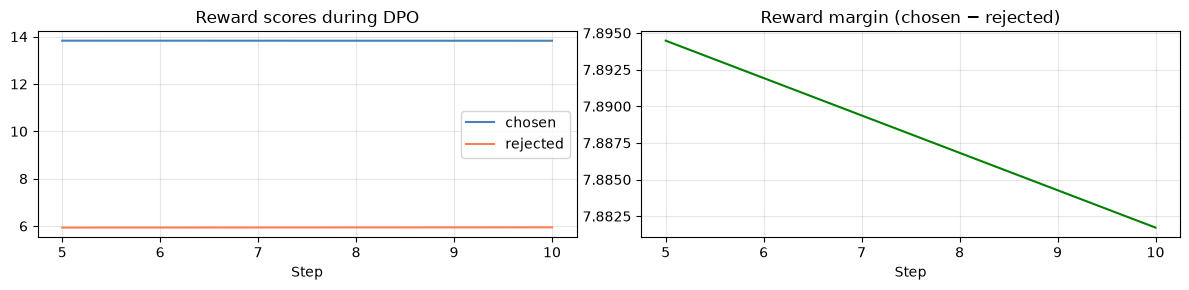

chosen reward ↑ and rejected reward ↓  →  the model is learning preferences


In [13]:
# Plot chosen vs rejected rewards over training
log = dpo_trainer.state.log_history
steps    = [x["step"]                    for x in log if "rewards/chosen" in x]
chosen   = [x["rewards/chosen"]          for x in log if "rewards/chosen" in x]
rejected = [x.get("rewards/rejected", 0) for x in log if "rewards/chosen" in x]
margins  = [x.get("rewards/margins", 0)  for x in log if "rewards/chosen" in x]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(steps, chosen,   label="chosen",   color="steelblue")
axes[0].plot(steps, rejected, label="rejected", color="coral")
axes[0].set_title("Reward scores during DPO"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(steps, margins, color="green")
axes[1].set_title("Reward margin (chosen − rejected)"); axes[1].grid(True, alpha=0.3)
for ax in axes: ax.set_xlabel("Step")
plt.tight_layout(); plt.show()
print("chosen reward ↑ and rejected reward ↓  →  the model is learning preferences")

## 4. LoRA: Parameter-Efficient Fine-Tuning

Full fine-tuning updates every parameter. For a 70B model that means ~560 GB of memory.

**LoRA** adds tiny **low-rank matrices** alongside the frozen original weights:
$$W' = W + \alpha \cdot \underbrace{B}_{d \times r} \underbrace{A}_{r \times d}, \quad r \ll d$$

Only $A$ and $B$ are trained. After training, they can be **merged back** into $W$, with zero overhead at inference.

### 4.1 LoRA from scratch

In [14]:
class LoRALinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int = 8, alpha: int = 16):
        super().__init__()
        self.original = original
        self.original.weight.requires_grad_(False)    # freeze original
        if self.original.bias is not None:
            self.original.bias.requires_grad_(False)
        d_out, d_in = original.weight.shape
        self.scaling = alpha / rank
        self.lora_A  = nn.Parameter(torch.randn(rank, d_in) * 0.01)
        self.lora_B  = nn.Parameter(torch.zeros(d_out, rank))   # B=0 → ΔW=0 at init

    def forward(self, x):
        return self.original(x) + (x @ self.lora_A.T @ self.lora_B.T) * self.scaling

    def merge(self) -> nn.Linear:
        self.original.weight.data += self.scaling * (self.lora_B @ self.lora_A)
        return self.original

# Show savings for a d=768 matrix (e.g. BERT-base)
d = 768
orig = nn.Linear(d, d, bias=False)
print(f"{'Rank':<6} {'Trainable':>12} {'% of total':>12} {'Compression':>12}")
print("-" * 46)
for r in [4, 8, 16, 32, 64]:
    lora = LoRALinear(orig, rank=r)
    t    = lora.lora_A.numel() + lora.lora_B.numel()
    tot  = orig.weight.numel() + t
    print(f"{r:<6} {t:>12,} {t/tot:>11.2%} {tot/t:>11.0f}x")

Rank      Trainable   % of total  Compression
----------------------------------------------
4             6,144       1.03%          97x
8            12,288       2.04%          49x
16           24,576       4.00%          25x
32           49,152       7.69%          13x
64           98,304      14.29%           7x


### 4.2 LoRA with PEFT (recommended)

In [15]:
from peft import LoraConfig, get_peft_model

base = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=torch.bfloat16)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],   # apply LoRA to Q and V attention projections
    lora_dropout=0.05,
    bias="none",
)

lora_model = get_peft_model(base, lora_config)
lora_model.print_trainable_parameters()

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

trainable params: 921,600 || all params: 135,436,608 || trainable%: 0.6805


### 4.3 Training with LoRA

In [16]:
from trl import SFTTrainer, SFTConfig

lora_model = lora_model.to(device)

lora_config_train = SFTConfig(
    output_dir="/tmp/lora_smollm",
    num_train_epochs=20,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=5e-4,
    warmup_steps=10,
    logging_steps=20,
    save_strategy="no",
    bf16=(device != "cpu"),
    report_to="none",
    max_length=256,
)

lora_trainer = SFTTrainer(
    model=lora_model,
    args=lora_config_train,
    train_dataset=sft_dataset,
    processing_class=sft_tokenizer,
)

print("Starting LoRA fine-tuning...")
lora_result = lora_trainer.train()
print(f"Done. Final loss: {lora_result.training_loss:.4f}")

/var/folders/n8/m5ycpkr13jj_w9jqvc_5djqw0000gp/T/ipykernel_183/2283312938.py:5: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  lora_config_train = SFTConfig(


Adding EOS to train dataset:   0%|          | 0/44 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/44 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1, 'pad_token_id': 2}.


Starting LoRA fine-tuning...


Step,Training Loss
20,4.710153
40,2.291697
60,1.345324
80,1.063990
100,0.964211
120,0.915977


Done. Final loss: 1.8819


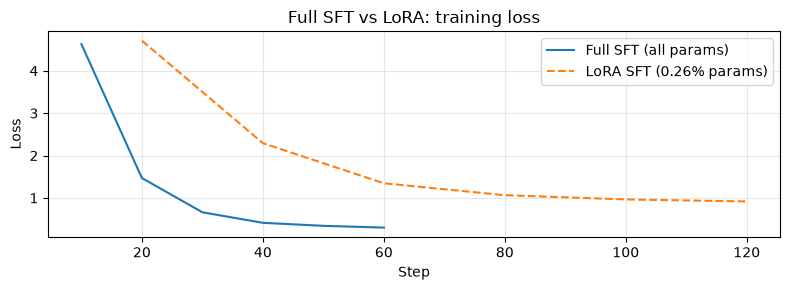

In [17]:
# Compare loss curves: full SFT vs LoRA
def get_curve(tr):
    log = tr.state.log_history
    return [x["step"] for x in log if "loss" in x], [x["loss"] for x in log if "loss" in x]

sft_s,  sft_l  = get_curve(trainer)
lora_s, lora_l = get_curve(lora_trainer)

plt.figure(figsize=(8, 3))
plt.plot(sft_s,  sft_l,  label="Full SFT (all params)")
plt.plot(lora_s, lora_l, label="LoRA SFT (0.26% params)", linestyle="--")
plt.xlabel("Step"); plt.ylabel("Loss")
plt.title("Full SFT vs LoRA: training loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### 4.4 Merging LoRA back into the base weights

In [18]:
# Merge adapter → plain model, zero inference overhead
merged_model = lora_model.merge_and_unload().to(device).eval()
print("Type after merge:", type(merged_model).__name__)

# Quick test
q = "What is the capital of France?"
print(f"Q: {q}")
print(f"A: {generate(make_prompt(q), mdl=merged_model, tok=sft_tokenizer)}")

Type after merge: LlamaForCausalLM
Q: What is the capital of France?
A: The capital of France is Paris.


## 5. GRPO: Group Relative Policy Optimization

GRPO is used for tasks with a **verifiable reward** (math, code, logic).

**Key insight**: instead of a value model, use the *group average reward* as a baseline.
This cuts memory from 4 models (PPO) to 2.

### 5.1 Group-relative advantages

In [19]:
def grpo_advantages(rewards: torch.Tensor) -> torch.Tensor:
    """Normalize rewards within a group to zero mean, unit variance."""
    mean, std = rewards.mean(), rewards.std()
    return torch.zeros_like(rewards) if std < 1e-8 else (rewards - mean) / std

# 8 answers to a math question: 4 correct, 4 wrong
correct   = torch.tensor([1, 0, 1, 0, 0, 1, 0, 1], dtype=torch.float)
format_ok = torch.tensor([1, 0, 1, 1, 0, 1, 0, 1], dtype=torch.float)
rewards   = correct + 0.1 * format_ok   # correctness + small format bonus

adv = grpo_advantages(rewards)
print(f"{'Answer':<10} {'Correct?':<10} {'Reward':<10} {'Advantage'}")
print("-" * 45)
for i in range(8):
    print(f"{'correct' if correct[i] else 'wrong':<10} {bool(correct[i])!s:<10} "
          f"{rewards[i]:.2f}       {adv[i]:+.3f}")
print(f"\nMean={adv.mean():.4f}  Std={adv.std():.4f}  (always ≈ 0 and 1 by construction)")

Answer     Correct?   Reward     Advantage
---------------------------------------------
correct    True       1.10       +0.934
wrong      False      0.00       -0.977
correct    True       1.10       +0.934
wrong      False      0.10       -0.804
wrong      False      0.00       -0.977
correct    True       1.10       +0.934
wrong      False      0.00       -0.977
correct    True       1.10       +0.934

Mean=0.0000  Std=1.0000  (always ≈ 0 and 1 by construction)


### 5.2 Toy GRPO training loop

A single-parameter model learns to answer correctly more than 50% of the time.

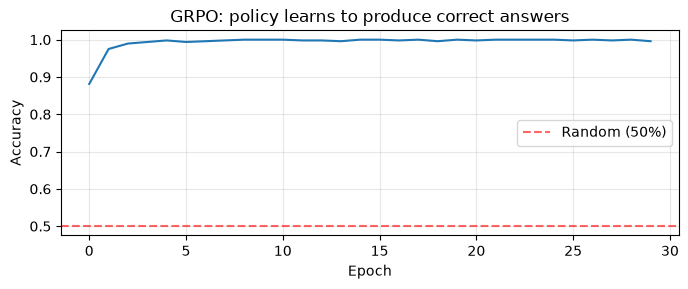

Final P(correct): 99.91%


In [20]:
def simulate_grpo(num_prompts=60, group_size=8, num_epochs=30):
    logit = nn.Parameter(torch.tensor(0.0))   # P(correct) = sigmoid(logit) = 0.5 initially
    opt   = torch.optim.SGD([logit], lr=0.3)
    history = []
    for _ in range(num_epochs):
        total = 0
        for _ in range(num_prompts):
            p       = torch.sigmoid(logit)
            correct = torch.bernoulli(p.expand(group_size).detach())
            adv     = grpo_advantages(correct)
            log_p   = correct * F.logsigmoid(logit) + (1-correct) * F.logsigmoid(-logit)
            loss    = -(log_p * adv.detach()).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            total  += correct.sum().item()
        history.append(total / (num_prompts * group_size))
    return history, torch.sigmoid(logit).item()

hist, p_final = simulate_grpo()

plt.figure(figsize=(7, 3))
plt.plot(hist)
plt.axhline(0.5, color="red", linestyle="--", alpha=0.6, label="Random (50%)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("GRPO: policy learns to produce correct answers")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f"Final P(correct): {p_final:.2%}")

### 5.3 Why GRPO is cheaper than PPO

In [21]:
methods = {
    "SFT":         {"models": ["policy"],                                     "n": 1},
    "DPO":         {"models": ["policy", "reference"],                        "n": 2},
    "GRPO":        {"models": ["policy", "reference"],                        "n": 2},
    "RLHF (PPO)":  {"models": ["policy", "value", "reference", "reward"],     "n": 4},
}
GB_per_model = 140   # ~70B model in BF16

print(f"{'Method':<15} {'Models in memory':<50} {'Memory (70B)':>14}")
print("-" * 80)
for name, info in methods.items():
    print(f"{name:<15} {', '.join(info['models']):<50} {info['n']*GB_per_model:>12} GB")

Method          Models in memory                                     Memory (70B)
--------------------------------------------------------------------------------
SFT             policy                                                      140 GB
DPO             policy, reference                                           280 GB
GRPO            policy, reference                                           280 GB
RLHF (PPO)      policy, value, reference, reward                            560 GB


## 6. Comparing all models

Let's run a few questions through all three fine-tuned models.

In [22]:
def compare(question):
    prompt = sft_tokenizer.apply_chat_template(
        [{"role":"system","content":"You are a helpful assistant."},
         {"role":"user","content":question}],
        tokenize=False, add_generation_prompt=True
    )
    print(f"Q: {question}")
    for label, mdl in [("SFT", sft_model), ("DPO", dpo_model), ("LoRA", merged_model)]:
        ans = generate(prompt, mdl=mdl, tok=sft_tokenizer, max_new_tokens=50)
        print(f"  {label+':':<6} {ans}")
    print(f"  {'Ref:':<6} {generate(make_prompt(question), max_new_tokens=50)}")
    print()

for q in ["What is the capital of France?", "What is 7 × 8?", "Define gradient descent."]:
    compare(q)

Q: What is the capital of France?
  SFT:   The capital of France is Paris.
  DPO:   The capital of France is Paris.
  LoRA:  The capital of France is Paris.
  Ref:   The capital of France is Paris.

Q: What is 7 × 8?
  SFT:   7 × 8 = 56.
  DPO:   7 × 8 = 56.
  LoRA:  7 × 8 = 56.
  Ref:   To find 7 × 8, we need to follow these steps:

First, we multiply 7 by itself 7 times:

7 × 7 = 49

Then, we multiply 49 by 8

Q: Define gradient descent.
  SFT:   Gradient descent iteratively adjusts parameters to minimize a loss function.
  DPO:   Gradient descent iteratively adjusts parameters to minimize a loss function.
  LoRA:  Gradient descent iteratively updates the parameters of a neural network.
  Ref:   Gradient descent is a type of optimization algorithm used to find the minimum of a function. It is a widely used method for minimizing a function by iteratively updating the parameters of the function to reduce the difference between the observed and predicted values.



